In [2]:
import numpy as np
import tidy3d as td
import tidy3d.web as web
import autograd as ad
from autograd import value_and_grad
import autograd.numpy as anp
from tidy3d.plugins.autograd import rescale
import matplotlib.pyplot as plt
import nlopt
import time

z pos -0.9 -0.6499999999999999


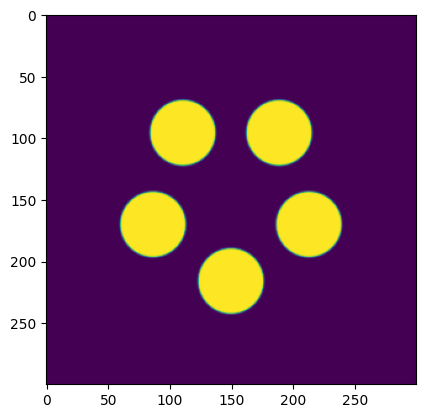

In [5]:
lambda_0 = 1.05
f0 = td.C_0 / lambda_0
fwidth = f0 / 100
run_time = 25 / fwidth
#run_time = 10 / fwidth

hx = hy = hz = 0.6
lz = 2
r_design = 0.3
r_0 = 0.08
width = 0.002
dl = 30
nx = ny = 300
nz = 300
eps_spheres = 3.5**2
eps_embedding = 1.5**2

b_spec = td.BoundarySpec(
    x=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
    y=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
    z=td.Boundary(minus=td.PML(), plus=td.PML()),
)

R = 0.2
zmax = 0.0
num = 5
ni = np.linspace(0, 360.0, num + 1)[:-1]
x = R * np.cos(ni * np.pi / 180.0)
y = R * np.sin(ni * np.pi / 180.0)
z = np.linspace(-zmax, zmax, x.shape[0])
positions = np.array([x, y, z]).T
radii = np.ones_like(positions[:, 0]) * r_0
params_0 = np.column_stack((radii, positions))

cur_it = 0

def place_spheres_tanh(params, x_size, y_size, z_size,  nx, ny, nz, width):
    """
    Keeping squared
    """
    x = anp.linspace(-x_size/2, x_size/2, nx)
    y = anp.linspace(-y_size/2, y_size/2, ny)
    z = anp.linspace(-z_size/2, z_size/2, nz)
    xx, yy, zz = anp.meshgrid(x, y, z, indexing="ij")

    radii = params[:, 0]        # (N,)
    centers = params[:, 1:4]    # (N,3)

    dx = xx[..., None] - centers[:, 0]
    dy = yy[..., None] - centers[:, 1]
    dz = zz[..., None] - centers[:, 2]

    sqdist = dx*dx + dy*dy + dz*dz                 # no sqrt
    denom = 2.0 * radii * width                   # same shape (N,)

    arg = (sqdist - radii**2) / denom
    
    # dist = anp.sqrt(sqdist + 1e-18)
    # arg = (dist - radii) / width
    arg = anp.clip(arg, -15.0, 15.0)   

    sph = 0.5 * (1.0 - anp.tanh(arg))
    rho = 1.0 - anp.prod(1.0 - sph, axis=-1)
    return rho

x_size = 2*r_design + 0.3
y_size = 2*r_design + 0.3
z_size = 2*r_design

# eps_box_pad = 1e-6
# x_size = hx - eps_box_pad
# y_size = hy - eps_box_pad
# z_size = 2 * r_design

circle = place_spheres_tanh(params_0, x_size, y_size, z_size, nx, ny, nz, width)
plt.imshow(circle[:, :, circle.shape[0]//2])

# p = pv.Plotter()
# data = pv.wrap(np.array(circle))
# # data.spacing = (0.9/(nx-1), 0.9/(ny-1), 0.6/(nz-1))
# # data.origin = (-0.45, -0.45, -0.3)
# data.spacing = (x_size/(nx-1), y_size/(ny-1), z_size/(nz-1))
# data.origin = (-x_size/2, -y_size/2, -z_size/2)
# p = pv.Plotter()
# p.add_mesh(data.contour(), cmap='binary')
# p.show_bounds(xtitle='x (µm)', ytitle='y (µm)', ztitle='z (µm)')
# p.show()

gaussian = td.GaussianPulse(freq0=f0, fwidth=fwidth)

z_pos_source = -hz/2 - (lz/2-hz/2)/2
z_pos_flux = -lz / 2 + 0.1
source_x_pol = td.PlaneWave(
    source_time=gaussian,
    size=(td.inf, td.inf, 0),
    center=(0, 0, z_pos_source),
    direction='+',
    pol_angle=0
)
source_y_pol = td.PlaneWave(
    source_time=gaussian,
    size=(td.inf, td.inf, 0),
    center=(0, 0, z_pos_source),
    direction='+',
    pol_angle=anp.pi / 2
)


print("z pos", z_pos_flux, z_pos_source)
flux_monitor = td.FieldMonitor(
    size=(td.inf, td.inf, 0),
    center=(0, 0, z_pos_flux),
    freqs=[f0],
    name="R",
)

perm_monitor = td.PermittivityMonitor(
    center=(0, 0, 0),
    size=(0, 2*r_design + 0.3, 2*r_design),
    freqs=[f0],
    name='Permittivity Monitor'
)

field_monitor = td.FieldMonitor(
    center=(0, 0, 0),
    size=(0, 2*r_design + 0.3, 2*r_design),
    freqs=[f0],
    name='Field Monitor'
)

def make_sim_empty(params):
    grid_spec = td.GridSpec.auto(
        wavelength=lambda_0,
        min_steps_per_wvl=dl
    )


    sim_x_pol = td.Simulation(
        size=(hx, hy, lz),
        grid_spec=grid_spec,
        medium=td.Medium(permittivity=eps_embedding),
        structures=[],
        sources=[source_x_pol],
        monitors=[flux_monitor, perm_monitor, field_monitor],
        run_time=run_time,
        shutoff=1e-04,
        boundary_spec=b_spec
    )
    return sim_x_pol

def make_sim(params):
    rho = place_spheres_tanh(params, x_size, y_size, z_size,  nx, ny, nz, width)

    eps = rescale(rho, eps_embedding, eps_spheres)

    grid_spec = td.GridSpec.auto(
        wavelength=lambda_0,
        min_steps_per_wvl=dl
    )

    # grid_spec = td.GridSpec.auto(
    #     wavelength=lambda_0,
    #     min_steps_per_wvl=30,   # or 40
    #     # override_structures=[
    #     #     td.MeshOverrideStructure(
    #     #         geometry=td.Box(center=(0, 0, 0), size=(0.5, 0.5, 0.5)),
    #     #         dl=(0.004, 0.004, 0.004),
    #     #     )
    #     # ],
    #     override_structures=[
    #     td.MeshOverrideStructure(
    #     geometry=td.Box(center=(0, 0, 0), size=(0.62, 0.62, 0.30)),
    #     dl=(0.004, 0.004, 0.004),
    #     )
    # ] 
    # )

    # grid_spec = td.GridSpec.uniform(dl=0.01)

    custom_structure = td.Structure.from_permittivity_array(
            geometry=td.Box(center=(0, 0, 0), size=(x_size, y_size, z_size)),
            eps_data=eps.reshape(eps.shape[0], eps.shape[1], eps.shape[2])
    )
    sim_x_pol = td.Simulation(
        size=(hx, hy, lz),
        grid_spec=grid_spec,
        medium=td.Medium(permittivity=eps_embedding),
        structures=[custom_structure],
        sources=[source_x_pol],
        monitors=[flux_monitor, perm_monitor, field_monitor],
        run_time=run_time,
        shutoff=1e-04,
        boundary_spec=b_spec
    )

    sim_y_pol = td.Simulation(
        size=(hx, hy, lz),
        grid_spec=grid_spec,
        medium=td.Medium(permittivity=eps_embedding),
        structures=[custom_structure],
        sources=[source_y_pol],
        monitors=[flux_monitor, perm_monitor, field_monitor],
        run_time=run_time,
        shutoff=1e-04,
        boundary_spec=b_spec
    )

    return sim_x_pol, sim_y_pol


def measure_reflectance(sim_data):
    return -sim_data["R"].flux.values

def obj(params):
    sim_x_pol, sim_y_pol = make_sim(params)
    sim_data_x_pol = web.run(sim_x_pol, task_name=f"x_pol_{cur_it}", folder_name="Five_Spheres", verbose=False)
    refl_x_pol = measure_reflectance(sim_data_x_pol)
    sim_data_y_pol = web.run(sim_y_pol, task_name=f"y_pol_{cur_it}", folder_name="Five_Spheres", verbose=False)
    refl_y_pol = measure_reflectance(sim_data_y_pol)
    print(refl_x_pol, refl_y_pol)
    return anp.abs(refl_x_pol - refl_y_pol)

In [4]:
def time_forward_only(params):
    t0 = time.perf_counter()
    v = obj(params)               
    t1 = time.perf_counter()
    return float(np.ravel(v)[0]), (t1 - t0)

def time_forward_plus_grad(params):
    t0 = time.perf_counter()
    v, g = value_and_grad(obj)(params)   
    t1 = time.perf_counter()
    return float(np.ravel(v)[0]), np.array(g), (t1 - t0)

v, tdiff = time_forward_only(params_0)
print("time forward", tdiff)
v, gfp, tfb = time_forward_plus_grad(params_0)
print("time forward_backward", tfb)
print("objective", v)

[0.03847688] [0.04057406]
time forward 66.21957342000678
Autograd ArrayBox with value [0.03847688] Autograd ArrayBox with value [0.04057406]
time forward_backward 301.2961199278943
objective 0.002097183318436148


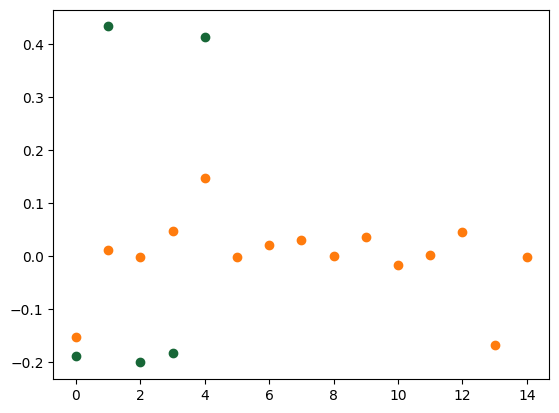

In [6]:
grad_rad =  gfp[:, 0]
grad_pos = gfp[:, 1:].flatten()
plt.scatter(np.arange(len(grad_rad)), grad_rad, label="wrt radii")
plt.scatter(np.arange(len(grad_pos)), grad_pos, label="wrt positions")

In [53]:

import h5py
with h5py.File(f"data_rcd_init_R_{R}_rinit_{r_0}_lz_{lz}_dl_{dl}_weight_{width}_dist_flux_{z_pos_flux}_source_{z_pos_source}_nx_{nx}_ny_{ny}_nz_{nz}.h5",'w') as f:
    f["gradients"] = gfp
    f["value"] = v
    f["time_forward"] =tdiff
    f["time_forward_backward"] = tfb